# Chest X-ray Classification: Hybrid Late Fusion (DenseNet121 + VGG16)

This notebook implements a strictly architected **Late Fusion** model for multi-label classification of Chest X-rays.

## architecture Overview
1. **Phase 1 (Primary)**: Train **DenseNet-121** (ImageNet weights). This is our anchor for Grad-CAM.
2. **Phase 2 (Auxiliary)**: Instantiate **VGG16** (Frozen). Used solely for additional texture feature extraction.
3. **Phase 3 (Fusion)**: Concatenate pooled features from both models and train a lightweight Classification Head.

## Compliance
- **Linkage**: Preserves original recursive glob data mapping.
- **Grad-CAM**: Strictly inference-only. No training-time overhead.
- **Output**: JSON-serializable predictions.

In [8]:
# --- CUDA Environment Setup ---
import os
import sys

# Attempt to add CUDA 12.9 to PATH if available
cuda_path = os.environ.get('CUDA_PATH_V12_9')
if cuda_path:
    print(f"Found CUDA 12.9 at: {cuda_path}")
    bin_path = os.path.join(cuda_path, 'bin')
    if bin_path not in os.environ['PATH']:
        os.environ['PATH'] = bin_path + os.pathsep + os.environ['PATH']
        print("Added CUDA bin to system PATH.")
    
    # Ensure CUDA_HOME is set
    if 'CUDA_HOME' not in os.environ:
        os.environ['CUDA_HOME'] = cuda_path
else:
    print("CUDA_PATH_V12_9 not found in environment variables. Checking standard CUDA_PATH...")
    cuda_path_std = os.environ.get('CUDA_PATH')
    if cuda_path_std:
        print(f"Found CUDA_PATH: {cuda_path_std}")

# --- Diagnostic: PyTorch Check (Requested) ---
try:
    import torch
    print("PyTorch Version:", torch.__version__)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"PyTorch Device: {device}")
    if device.type == 'cuda':
        print(f"PyTorch sees GPU: {torch.cuda.get_device_name(0)}")
except ImportError:
    print("PyTorch not installed. Skipping diagnostic.")
except Exception as e:
    print(f"PyTorch Diagnostic Error: {e}")

import os
import glob
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16, DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Input, Concatenate, Dropout, BatchNormalization
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer

# --- Configuration ---
IMG_SIZE = (224, 224)
BATCH_SIZE = 8 # Reduced from 32 for RTX 3050 Compatibility
EPOCHS_PHASE_1 = 10
EPOCHS_PHASE_3 = 10
LEARNING_RATE = 1e-4

# Paths (User specific)
DATA_ROOT = r"D:/VitalScanAI/backend/data/dataset"
CSV_PATH = "Data_Entry_2017.csv"
EXPORT_DIR = "./models_export/xray"
os.makedirs(EXPORT_DIR, exist_ok=True)

# --- GPU Configuration ---
print("TensorFlow Version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Currently, memory growth needs to be the same across GPUs
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        print("CUDA Activated: GPU is available.")
    except RuntimeError as e:
        # Memory growth must be set before GPUs have been initialized
        print(e)
else:
    print("WARNING: CUDA not available. Running on CPU.")


Found CUDA 12.9 at: C:\Program Files\NVIDIA GPU Computing Toolkit\CUDA\v12.9
PyTorch Version: 2.7.1+cu118
PyTorch Device: cuda
PyTorch sees GPU: NVIDIA GeForce RTX 3050 Laptop GPU
TensorFlow Version: 2.10.1
1 Physical GPUs, 1 Logical GPUs
CUDA Activated: GPU is available.


In [9]:
!nvidia-smi

Tue Jan 27 23:46:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 576.02                 Driver Version: 576.02         CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3050 ...  WDDM  |   00000000:01:00.0 Off |                  N/A |
| N/A   55C    P8             11W /   60W |    2517MiB /   4096MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Data Loading & Linkage
We preserve the critical logic of strictly mapping CSV entries to actual files found on disk.

In [10]:
# 1. Scan for all images recursively
image_paths = glob.glob(os.path.join(DATA_ROOT, '**', '*.png'), recursive=True)
print(f"Found {len(image_paths)} images in {DATA_ROOT}")

if len(image_paths) == 0:
    print("WARNING: No images found. Ensure dataset is downloaded.")
else:
    # Map filename -> full absolute path
    path_map = {os.path.basename(p): p for p in image_paths}

    # 2. Load Metadata
    try:
        label_df = pd.read_csv(CSV_PATH)
        print(f"CSV Entries: {len(label_df)}")
        
        # 3. Apply Linkage: Map CSV Image Index to Filesystem Path
        label_df['path'] = label_df['Image Index'].map(path_map)
        
        # 4. Filter Missing
        label_df = label_df.dropna(subset=['path'])
        print(f"Validated Dataset Size: {len(label_df)}")
        
        # 5. Process Labels
        label_df['labels'] = label_df['Finding Labels'].apply(lambda x: x.split('|'))
        mlb = MultiLabelBinarizer()
        mlb.fit(label_df['labels'])
        classes = mlb.classes_
        print(f"Classes ({len(classes)}): {classes}")
        
        # 6. Strict Splits
        train_val_df, test_df = train_test_split(label_df, test_size=0.20, random_state=42)
        train_df, val_df = train_test_split(train_val_df, test_size=0.125, random_state=42) # 0.125 * 0.8 = 0.1
        
        print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
        
    except FileNotFoundError:
        print("CSV file not found. Please ensure Data_Entry_2017.csv is present.")

# --- Class Balancing ---
from sklearn.utils import class_weight
import numpy as np

# Flatten all labels in train_df to compute weights
flat_labels = [l for sublist in train_df['labels'] for l in sublist]
all_classes = sorted(list(set(flat_labels)))

# Map class name to index
class_to_idx = {c: i for i, c in enumerate(classes)}

# Calculate weights (manual 'balanced' approach for multi-label)
from collections import Counter
counts = Counter(flat_labels)
total_samples = len(train_df)
class_weights = {}

print("\nComputed Class Weights:")
for c in classes:
    idx = class_to_idx[c]
    # Heuristic: total / count. 
    # We can normalize or leave raw. Keras handles raw.
    # 'balanced' style: total / (num_classes * count)
    cnt = counts.get(c, 0)
    if cnt > 0:
        # weight = total_samples / (len(classes) * cnt)
        # Simple inverse frequency often works best for 'No Finding' dominance
        weight = (total_samples / cnt)
        # Normalize so that 'No Finding' (majority) is closer to 1.0? 
        # Standard sklearn logic scales so that sum of weights * counts = total_samples
        # Let's stick to inverse frequency but log-dampened if it's too extreme, 
        # OR just standard inverse.
        # Given imbalance 23 vs 3700, 3700/23 = 160x weight. Use standard balanced.
        weight = total_samples / (len(classes) * cnt)
        class_weights[idx] = weight
        print(f"{c}: {weight:.4f}")
    else:
        class_weights[idx] = 1.0


Found 9529 images in D:/VitalScanAI/backend/data/dataset
CSV Entries: 112120
Validated Dataset Size: 9529
Classes (15): ['Atelectasis' 'Cardiomegaly' 'Consolidation' 'Edema' 'Effusion'
 'Emphysema' 'Fibrosis' 'Hernia' 'Infiltration' 'Mass' 'No Finding'
 'Nodule' 'Pleural_Thickening' 'Pneumonia' 'Pneumothorax']
Train: 6670 | Val: 953 | Test: 1906

Computed Class Weights:
Atelectasis: 0.7374
Cardiomegaly: 1.3117
Consolidation: 1.7169
Edema: 4.0424
Effusion: 0.7025
Emphysema: 3.3184
Fibrosis: 2.4567
Hernia: 19.3333
Infiltration: 0.4187
Mass: 1.9940
No Finding: 0.1170
Nodule: 1.5440
Pleural_Thickening: 2.0975
Pneumonia: 5.7749
Pneumothorax: 1.9167


In [11]:
# Generators
if 'train_df' in locals():
    # Enhanced Data Augmentation for Grad-CAM Improvement
    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True,
        brightness_range=[0.8, 1.2],
        fill_mode='nearest'
    )
    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    common_args = {
        'x_col': 'path',
        'y_col': 'labels',
        'target_size': IMG_SIZE,
        'batch_size': BATCH_SIZE,
        'class_mode': 'categorical',
        'classes': list(classes)
    }

    train_gen = train_datagen.flow_from_dataframe(dataframe=train_df, **common_args, shuffle=True)
    val_gen = val_datagen.flow_from_dataframe(dataframe=val_df, **common_args, shuffle=False)
    test_gen = val_datagen.flow_from_dataframe(dataframe=test_df, **common_args, shuffle=False)


Found 6670 validated image filenames belonging to 15 classes.
Found 953 validated image filenames belonging to 15 classes.
Found 1906 validated image filenames belonging to 15 classes.


## Phase 1: DenseNet-121 (Primary Branch)
We train the DenseNet-121 first. This model will later serve as the primary visual backbone and the source for Grad-CAM heatmaps.

In [12]:
def build_densenet(input_shape, num_classes):
    base_model = DenseNet121(weights='imagenet', include_top=False, input_shape=input_shape)
    
    # Optional: Freeze mostly, fine-tune later
    # For this phase, we let it be trainable or freeze headers
    # base_model.trainable = False 
    # Let's unfreeze top layers? For now, standard trainable=True from Keras default is fine (all trainable)

    x = base_model.output
    x = GlobalAveragePooling2D(name='densenet_gap')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    # Temporary head for Phase 1 training
    output = Dense(num_classes, activation='sigmoid', name='phase1_output')(x)
    
    model = Model(inputs=base_model.input, outputs=output, name="DenseNet_Phase1")
    return model

if 'train_gen' in locals():
    densenet_model = build_densenet(IMG_SIZE + (3,), len(classes))
    densenet_model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    # Checkpoints
    dense_ckpt = ModelCheckpoint(
        os.path.join(EXPORT_DIR, 'densenet_phase1_best.keras'),
        monitor='val_auc', save_best_only=True, mode='max', verbose=1
    )
    
    print("--- Starting Phase 1: DenseNet Training ---")
    history_p1 = densenet_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_PHASE_1,
        callbacks=[dense_ckpt, EarlyStopping(patience=3, restore_best_weights=True)],
        class_weight=class_weights
    )

--- Starting Phase 1: DenseNet Training ---
Epoch 1/10
834/834 [==============================] - ETA: 0s - loss: 0.4269 - accuracy: 0.0777 - auc: 0.5237
Epoch 1: val_auc improved from -inf to 0.59741, saving model to ./models_export/xray\densenet_phase1_best.keras
834/834 [==============================] - 373s 426ms/step - loss: 0.4269 - accuracy: 0.0777 - auc: 0.5237 - val_loss: 0.4085 - val_accuracy: 0.1301 - val_auc: 0.5974
Epoch 2/10
834/834 [==============================] - ETA: 0s - loss: 0.2408 - accuracy: 0.1069 - auc: 0.5731
Epoch 2: val_auc improved from 0.59741 to 0.70626, saving model to ./models_export/xray\densenet_phase1_best.keras
834/834 [==============================] - 341s 408ms/step - loss: 0.2408 - accuracy: 0.1069 - auc: 0.5731 - val_loss: 0.2925 - val_accuracy: 0.2613 - val_auc: 0.7063
Epoch 3/10
834/834 [==============================] - ETA: 0s - loss: 0.2178 - accuracy: 0.1145 - auc: 0.6130
Epoch 3: val_auc did not improve from 0.70626
834/834 [==========

## Phase 2: VGG16 (Auxiliary Texture Encoder)
We instantiate VGG16. **Crucially, we do not train this.** It provides complementary texture features.

In [13]:
def build_vgg_extractor(input_shape):
    vgg = VGG16(weights='imagenet', include_top=False, input_shape=input_shape)
    vgg.trainable = False # Strict architectural rule
    
    x = vgg.output
    x = GlobalAveragePooling2D(name='vgg_gap')(x)
    
    return Model(inputs=vgg.input, outputs=x, name="VGG_Extractor")

vgg_extractor = build_vgg_extractor(IMG_SIZE + (3,))

## Phase 3: Late Fusion
We construct the final model by fusing the trained DenseNet features (from Phase 1) and VGG features.

In [14]:
def build_late_fusion_model(densenet_p1, vgg_ext, num_classes):
    # 1. Input
    input_tensor = Input(shape=IMG_SIZE + (3,))
    
    # 2. Get features
    # We call the models on the input tensor
    # Note: We access the 'output' of the truncated models
    
    # Truncate DenseNet Phase 1 to remove the sigmoid head
    # The layer before 'phase1_output' was Dropout, before that BatchNorm, before that GAP
    # Let's get the GAP output directly for clean fusion
    dense_gap = densenet_p1.get_layer('densenet_gap').output
    dense_feat_model = Model(inputs=densenet_p1.input, outputs=dense_gap)
    dense_feat_model.trainable = False # Freeze for fusion training, or fine-tune
    
    # Get features
    dense_feats = dense_feat_model(input_tensor)
    vgg_feats = vgg_ext(input_tensor)
    
    # 3. Concatenate
    concat = Concatenate(name='late_fusion_concat')([dense_feats, vgg_feats])
    
    # 4. Classification Head
    x = Dense(512, activation='relu')(concat)
    x = Dropout(0.4)(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.3)(x)
    output = Dense(num_classes, activation='sigmoid', name='final_output')(x)
    
    return Model(inputs=input_tensor, outputs=output, name="Hybrid_Fusion_Model")

if 'densenet_model' in locals():
    hybrid_model = build_late_fusion_model(densenet_model, vgg_extractor, len(classes))
    hybrid_model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    
    fusion_ckpt = ModelCheckpoint(
        os.path.join(EXPORT_DIR, 'hybrid_fusion_best.keras'),
        monitor='val_auc', save_best_only=True, mode='max', verbose=1
    )
    
    print("--- Starting Phase 3: Late Fusion Training ---")
    hybrid_model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=EPOCHS_PHASE_3,
        callbacks=[fusion_ckpt, EarlyStopping(patience=3)],
        class_weight=class_weights
    )

--- Starting Phase 3: Late Fusion Training ---
Epoch 1/10
834/834 [==============================] - ETA: 0s - loss: 0.2435 - accuracy: 0.1060 - auc: 0.5819
Epoch 1: val_auc improved from -inf to 0.67199, saving model to ./models_export/xray\hybrid_fusion_best.keras
834/834 [==============================] - 274s 315ms/step - loss: 0.2435 - accuracy: 0.1060 - auc: 0.5819 - val_loss: 0.2664 - val_accuracy: 0.1291 - val_auc: 0.6720
Epoch 2/10
834/834 [==============================] - ETA: 0s - loss: 0.2262 - accuracy: 0.1087 - auc: 0.6037
Epoch 2: val_auc improved from 0.67199 to 0.70390, saving model to ./models_export/xray\hybrid_fusion_best.keras
834/834 [==============================] - 278s 333ms/step - loss: 0.2262 - accuracy: 0.1087 - auc: 0.6037 - val_loss: 0.2622 - val_accuracy: 0.1322 - val_auc: 0.7039
Epoch 3/10
834/834 [==============================] - ETA: 0s - loss: 0.2108 - accuracy: 0.1072 - auc: 0.6364
Epoch 3: val_auc did not improve from 0.70390
834/834 [===========

## 4. Grad-CAM & JSON Inference
Strict separation: We create a fresh model instance or use the trained one purely for inference logic, targeting `conv5_block16_concat` in the DenseNet branch.


running Evaluation on first 10 test samples...

1/1 [==============================] - 5s 5s/step
--- Sample 1/10 ---
File: 00000265_005.png
Ground Truth: ['No Finding']
Predictions:
[
  {
    "label": "Infiltration",
    "confidence": 0.2559961676597595
  },
  {
    "label": "Hernia",
    "confidence": 0.1629636585712433
  },
  {
    "label": "Mass",
    "confidence": 0.12103177607059479
  }
]


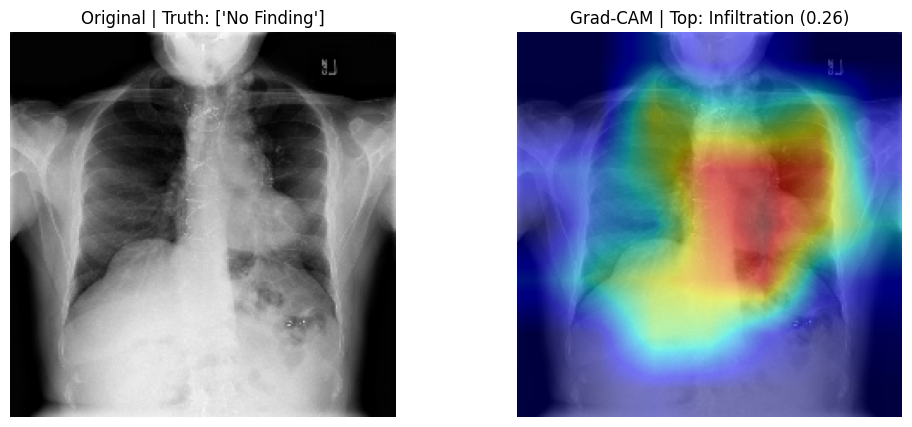

--------------------------------------------------
1/1 [==============================] - 0s 57ms/step
--- Sample 2/10 ---
File: 00004205_010.png
Ground Truth: ['No Finding']
Predictions:
[
  {
    "label": "Hernia",
    "confidence": 0.46494486927986145
  },
  {
    "label": "Infiltration",
    "confidence": 0.11563078314065933
  },
  {
    "label": "No Finding",
    "confidence": 0.0912623479962349
  }
]


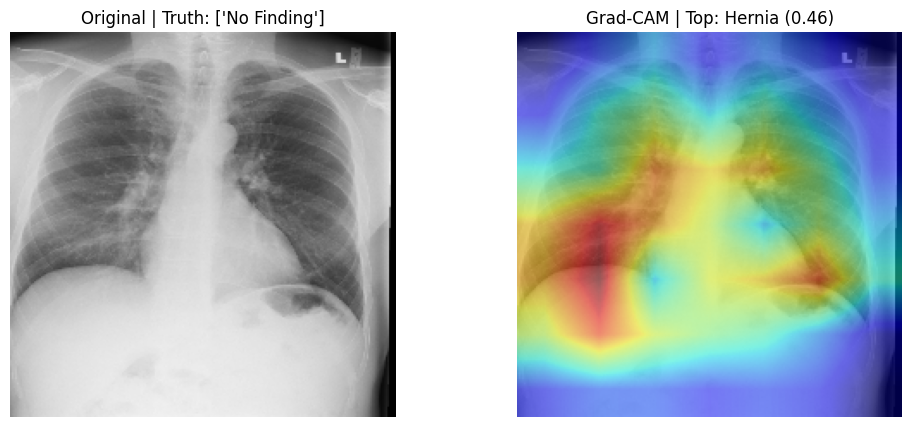

--------------------------------------------------
1/1 [==============================] - 0s 147ms/step
--- Sample 3/10 ---
File: 00004317_000.png
Ground Truth: ['Consolidation', 'Infiltration', 'Mass']
Predictions:
[
  {
    "label": "Infiltration",
    "confidence": 0.34931010007858276
  },
  {
    "label": "Effusion",
    "confidence": 0.285112589597702
  },
  {
    "label": "Edema",
    "confidence": 0.22711807489395142
  }
]


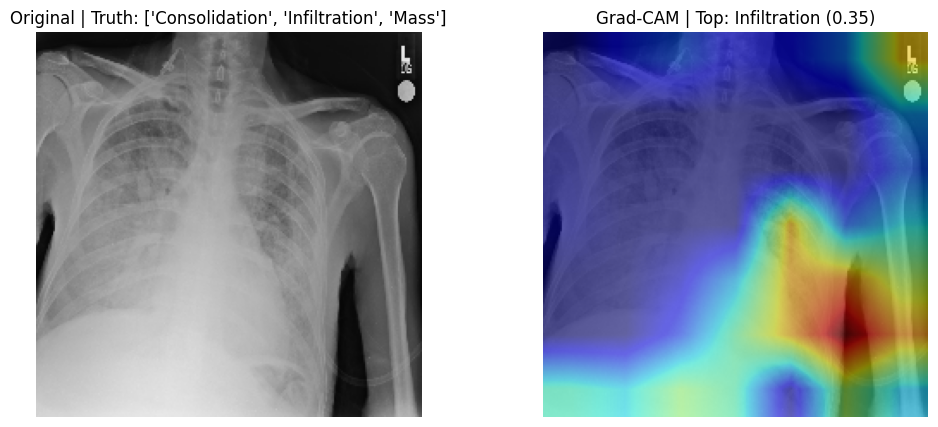

--------------------------------------------------
1/1 [==============================] - 0s 66ms/step
--- Sample 4/10 ---
File: 00006271_059.png
Ground Truth: ['No Finding']
Predictions:
[
  {
    "label": "Infiltration",
    "confidence": 0.366222083568573
  },
  {
    "label": "Effusion",
    "confidence": 0.20256416499614716
  },
  {
    "label": "Edema",
    "confidence": 0.16879577934741974
  }
]


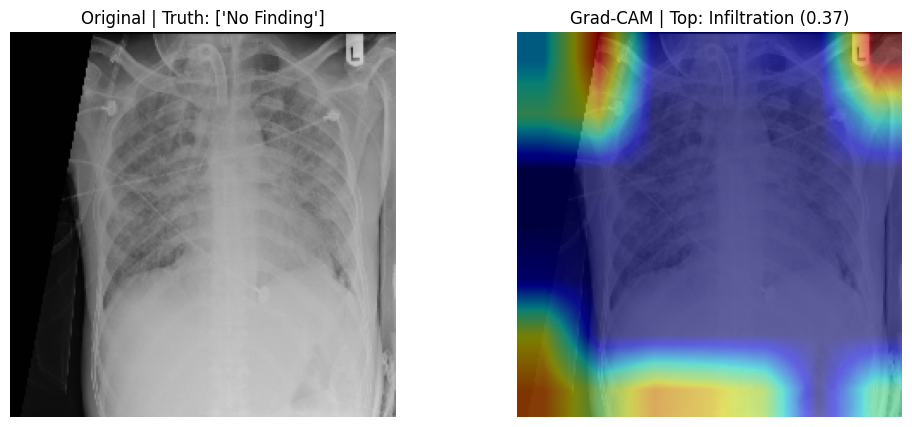

--------------------------------------------------
1/1 [==============================] - 0s 56ms/step
--- Sample 5/10 ---
File: 00004752_000.png
Ground Truth: ['No Finding']
Predictions:
[
  {
    "label": "Emphysema",
    "confidence": 0.14810387790203094
  },
  {
    "label": "Nodule",
    "confidence": 0.14762245118618011
  },
  {
    "label": "Mass",
    "confidence": 0.14022015035152435
  }
]


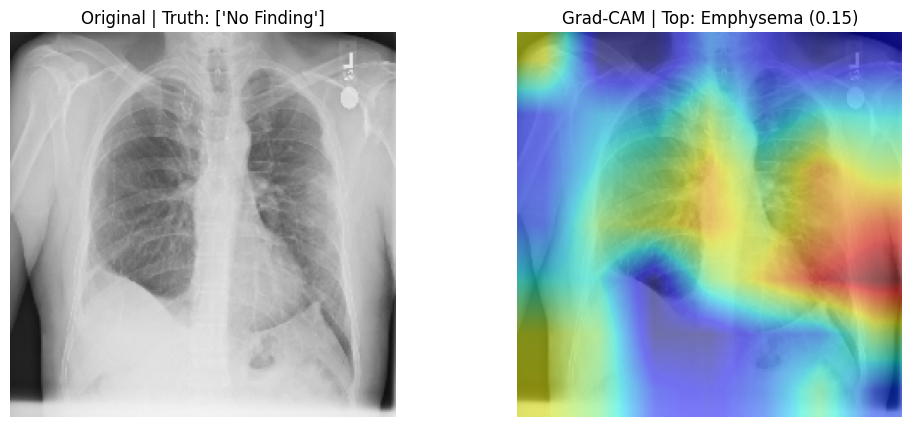

--------------------------------------------------
1/1 [==============================] - 0s 59ms/step
--- Sample 6/10 ---
File: 00000870_006.png
Ground Truth: ['No Finding']
Predictions:
[
  {
    "label": "Infiltration",
    "confidence": 0.24973773956298828
  },
  {
    "label": "Effusion",
    "confidence": 0.21037152409553528
  },
  {
    "label": "Cardiomegaly",
    "confidence": 0.17785675823688507
  }
]


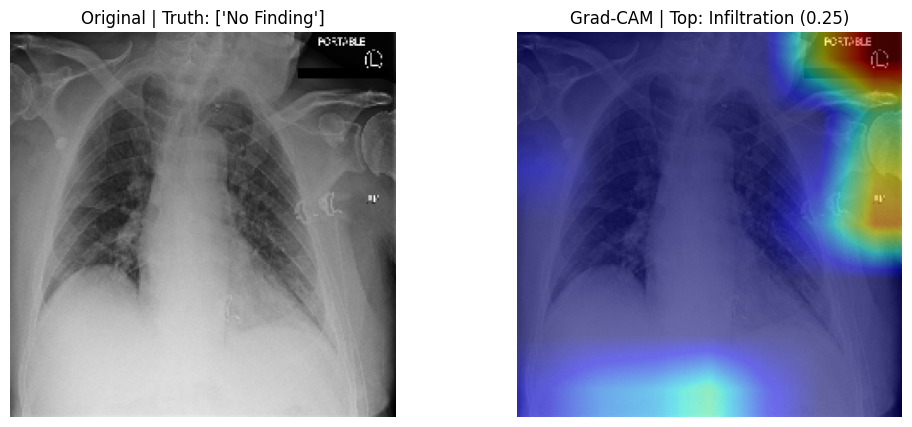

--------------------------------------------------
1/1 [==============================] - 0s 69ms/step
--- Sample 7/10 ---
File: 00000798_033.png
Ground Truth: ['Infiltration']
Predictions:
[
  {
    "label": "Effusion",
    "confidence": 0.2081180214881897
  },
  {
    "label": "Infiltration",
    "confidence": 0.17547541856765747
  },
  {
    "label": "Atelectasis",
    "confidence": 0.1424829512834549
  }
]


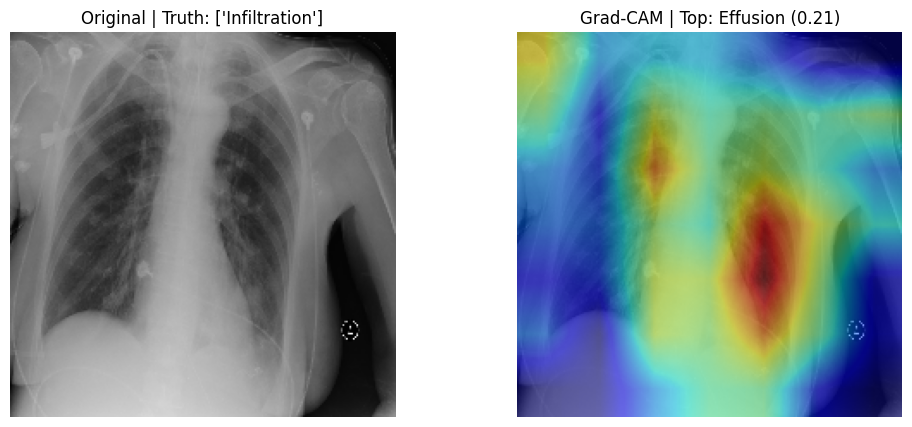

--------------------------------------------------
1/1 [==============================] - 0s 58ms/step
--- Sample 8/10 ---
File: 00000404_001.png
Ground Truth: ['Atelectasis', 'Consolidation', 'Effusion', 'Mass', 'Pleural_Thickening']
Predictions:
[
  {
    "label": "Infiltration",
    "confidence": 0.22241240739822388
  },
  {
    "label": "Pneumothorax",
    "confidence": 0.18575623631477356
  },
  {
    "label": "Effusion",
    "confidence": 0.16758820414543152
  }
]


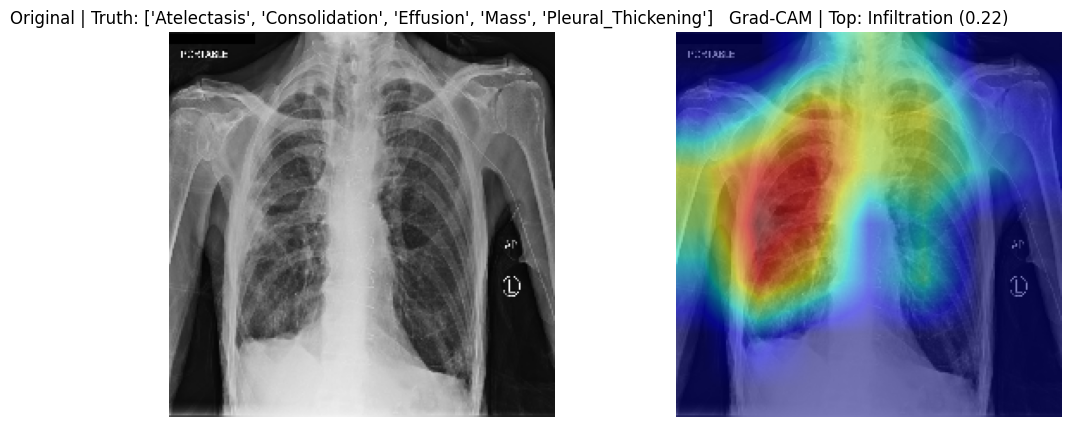

--------------------------------------------------
1/1 [==============================] - 0s 63ms/step
--- Sample 9/10 ---
File: 00000649_000.png
Ground Truth: ['Pleural_Thickening']
Predictions:
[
  {
    "label": "Infiltration",
    "confidence": 0.18925312161445618
  },
  {
    "label": "Hernia",
    "confidence": 0.15800105035305023
  },
  {
    "label": "No Finding",
    "confidence": 0.12394373118877411
  }
]


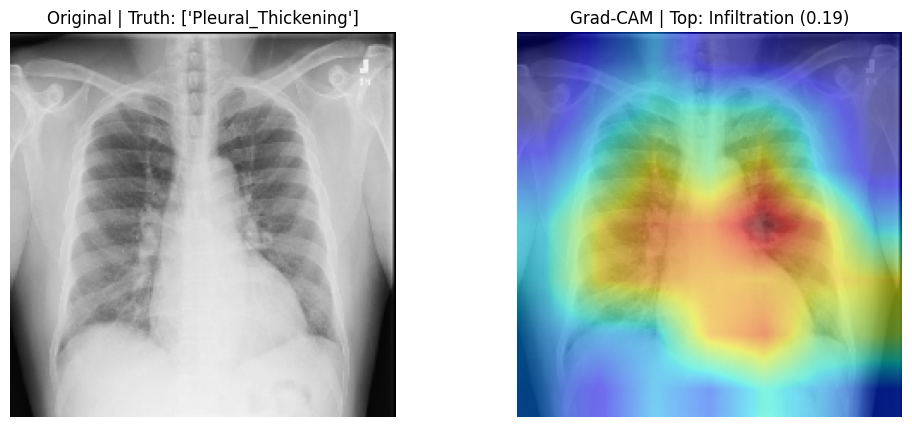

--------------------------------------------------
1/1 [==============================] - 0s 84ms/step
--- Sample 10/10 ---
File: 00004831_002.png
Ground Truth: ['No Finding']
Predictions:
[
  {
    "label": "Infiltration",
    "confidence": 0.21470537781715393
  },
  {
    "label": "No Finding",
    "confidence": 0.13693177700042725
  },
  {
    "label": "Cardiomegaly",
    "confidence": 0.11794421821832657
  }
]


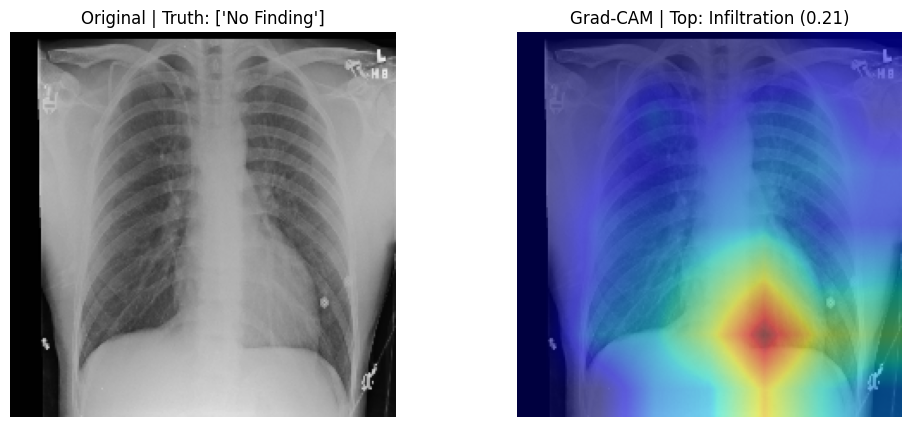

--------------------------------------------------


In [15]:
def compute_gradcam(model, img_array, layer_name='conv5_block16_concat'):
    """
    Generates Grad-CAM heatmap for the top predicted class.
    Finds the target layer within the nested DenseNet structure.
    """
    # 1. Find the inner DenseNet model if nested
    try:
        target_layer = model.get_layer(layer_name)
    except ValueError:
        print(f"Layer {layer_name} not found in top model. Using standalone DenseNet logic.")
        return np.zeros((224,224))

    grad_model = Model(
        inputs=model.inputs,
        outputs=[target_layer.output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    # Resize to match input image dimensions (224, 224)
    heatmap = tf.expand_dims(heatmap, axis=-1)
    heatmap = tf.image.resize(heatmap, (224, 224))
    heatmap = tf.squeeze(heatmap)
    return heatmap.numpy()

def predict_json(img_path, inference_model, gradcam_model, classes):
    img = load_img(img_path, target_size=IMG_SIZE)
    img_arr = img_to_array(img)
    # Preprocessing: Use the same function as training (no manual /255.0)
    img_arr = np.expand_dims(img_arr, axis=0)
    img_arr = preprocess_input(img_arr)
    
    # Inference
    probs = inference_model.predict(img_arr)[0]
    
    # Top 3
    top_indices = probs.argsort()[-3:][::-1]
    findings = [
        {"label": classes[i], "confidence": float(probs[i])} 
        for i in top_indices
    ]
    
    # Grad-CAM 
    heatmap = compute_gradcam(gradcam_model, img_arr, 'conv5_block16_concat')
    
    return {
        "image": img_path,
        "findings": findings,
        "gradcam": heatmap
    }

# --- Batch Test (10 Samples) ---
if 'test_df' in locals() and len(test_df) > 0:
    num_samples = 10
    print(f"\nrunning Evaluation on first {num_samples} test samples...\n")
    
    for i in range(num_samples):
        row = test_df.iloc[i]
        sample_path = row['path']
        true_labels = row['labels']
        filename = os.path.basename(sample_path)
        
        result = predict_json(sample_path, hybrid_model, densenet_model, classes)
        
        # Text Output
        print(f"--- Sample {i+1}/{num_samples} ---")
        print(f"File: {filename}")
        print(f"Ground Truth: {true_labels}")
        print("Predictions:")
        print(json.dumps(result['findings'], indent=2))
        
        # Visualization
        plt.figure(figsize=(12, 5))
        
        # Original
        img = load_img(result['image'], target_size=IMG_SIZE)
        plt.subplot(1, 2, 1)
        plt.imshow(img)
        plt.title(f"Original | Truth: {true_labels}")
        plt.axis('off')
        
        # Grad-CAM
        plt.subplot(1, 2, 2)
        plt.imshow(img)
        plt.imshow(result['gradcam'], cmap='jet', alpha=0.5)
        plt.title(f"Grad-CAM | Top: {result['findings'][0]['label']} ({result['findings'][0]['confidence']:.2f})")
        plt.axis('off')
        plt.show()
        print("-"*50)


In [16]:
# --- Analysis of Class Imbalance ---
if 'train_df' in locals():
    print("\n--- Class Distribution in Training Set ---")
    # Flatten the list of labels
    all_labels = [label for sublist in train_df['labels'] for label in sublist]
    from collections import Counter
    counts = Counter(all_labels)
    import pandas as pd
    df_counts = pd.DataFrame.from_dict(counts, orient='index', columns=['Count']).sort_values('Count', ascending=False)
    print(df_counts)
    print(f"\nTotal Training Images: {len(train_df)}")
    
    # Check No Finding Ratio
    no_finding_count = counts.get('No Finding', 0)
    print(f"'No Finding' ratio: {no_finding_count / len(train_df):.2%}")



--- Class Distribution in Training Set ---
                    Count
No Finding           3799
Infiltration         1062
Effusion              633
Atelectasis           603
Cardiomegaly          339
Nodule                288
Consolidation         259
Pneumothorax          232
Mass                  223
Pleural_Thickening    212
Fibrosis              181
Emphysema             134
Edema                 110
Pneumonia              77
Hernia                 23

Total Training Images: 6670
'No Finding' ratio: 56.96%
